<a href="https://colab.research.google.com/github/HarithaGottumukkala/DATA266-1598_hw3/blob/main/HARITHA_Homework3_1598.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import torch

# Personal parameters
SID4 = 1598
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"SID4: {SID4}")
print(f"SEED: {SEED}")
print(f"SLICE: {SLICE}")
print(f"HP_ID: {HP_ID}")
print(f"CLS_A: {CLS_A}")
print(f"CLS_B: {CLS_B}")

SID4: 1598
SEED: 1598
SLICE: 598
HP_ID: 2
CLS_A: 8
CLS_B: 5


### 1.Try out and experiment the following different prompt engineering techniques with your own examples (math problems, logical reasoning tasks, or text-based tasks). For each prompt engineering technique listed below, you must provide two different prompt examples (i.e., two separate code snippets per technique): (5 Marks)
###  Zero-Shot, Few-Shot, Chain-of-Thought, Zero-Shot CoT, Meta-Prompting, and Tree of Thoughts.
### Compare how the outputs differ and document findings.


In [2]:
%pip install -q langchain-ollama reportlab

print("Package setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.8 MB/s eta 0:00:00
Package setup complete.


In [3]:
import sys
from pathlib import Path
from datetime import datetime, timezone

ARTIFACT_DIR = Path("hw3_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

log_file = open(
    ARTIFACT_DIR / "RUN_LOG.txt",
    "w",
    buffering=1
)

class Tee:
    # Show output in Colab and save the same output to a file.
    def __init__(self, console):
        self.console = console

    def write(self, text):
        self.console.write(text)
        log_file.write(text)

    def flush(self):
        self.console.flush()
        log_file.flush()

    def __getattr__(self, name):
        return getattr(self.console, name)

sys.stdout = Tee(sys.stdout)
sys.stderr = Tee(sys.stderr)

print("Run started:", datetime.now(timezone.utc).isoformat())
print(
    f"SID4={SID4}, SEED={SEED}, SLICE={SLICE}, "
    f"HP_ID={HP_ID}, CLS_A={CLS_A}, CLS_B={CLS_B}"
)
print("Results folder:", ARTIFACT_DIR)

Run started: 2026-09-15T07:19:36.350143+00:00
SID4=1598, SEED=1598, SLICE=598, HP_ID=2, CLS_A=8, CLS_B=5
Results folder: hw3_artifacts


## Part 1: Prompt Engineering

I will use `qwen2.5:3b` through Ollama and LangChain.

I will test Zero-Shot, Few-Shot, Chain-of-Thought, Zero-Shot CoT, Meta-Prompting, and Tree of Thoughts. Each technique will have two separate examples.

I will use the same math problem and logic puzzle across all techniques to compare answer correctness, explanation length, and runtime.

In [4]:
import subprocess
import shutil
import time
import requests
import json

def run_setup(command):
    print("Running:", " ".join(command))

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    print(result.stdout)
    result.check_returncode()

# Ollama's installer may need zstd to unpack its files.
if shutil.which("ollama") is None:
    if shutil.which("zstd") is None:
        run_setup(["apt-get", "update", "-qq"])
        run_setup(["apt-get", "install", "-y", "-qq", "zstd"])

    run_setup([
        "curl", "-fsSL",
        "https://ollama.com/install.sh",
        "-o", "/tmp/ollama_install.sh"
    ])
    run_setup(["sh", "/tmp/ollama_install.sh"])

print("Ollama installation complete.")

Running: apt-get update -qq
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

Running: apt-get install -y -qq zstd
Selecting previously unselected package zstd.
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 9

In [5]:
BASE_URL = "http://127.0.0.1:11434"
MODEL_NAME = "qwen2.5:3b"

def ollama_ready():
    try:
        response = requests.get(BASE_URL + "/api/tags", timeout=2)
        return response.ok
    except requests.RequestException:
        return False

# Start the server if it is not already running.
if not ollama_ready():
    server_log = open(ARTIFACT_DIR / "OLLAMA_LOG.txt", "a")

    ollama_process = subprocess.Popen(
        ["ollama", "serve"],
        stdout=server_log,
        stderr=server_log
    )

    for _ in range(60):
        if ollama_ready():
            break
        time.sleep(1)

    if not ollama_ready():
        raise RuntimeError("Ollama did not start. Check OLLAMA_LOG.txt.")

print("Ollama server is ready.")
print("Downloading", MODEL_NAME, "— please wait.")

response = requests.post(
    BASE_URL + "/api/pull",
    json={"model": MODEL_NAME, "stream": False},
    timeout=1800
)
response.raise_for_status()

download_result = response.json()
if "error" in download_result:
    raise RuntimeError(download_result["error"])

print("Download result:", download_result)

# Save the model details for reproducibility.
model_details = requests.get(
    BASE_URL + "/api/tags", timeout=10
).json()

(ARTIFACT_DIR / "ollama_models.json").write_text(
    json.dumps(model_details, indent=2)
)

run_setup(["ollama", "--version"])
print("Ollama model setup complete.")

Ollama server is ready.
Download result: {'status': 'success'}
Running: ollama --version
ollama version is 0.34.0

Ollama model setup complete.


In [6]:
from langchain_ollama import ChatOllama
import platform
import importlib.metadata

llm = ChatOllama(
    model=MODEL_NAME,
    base_url=BASE_URL,
    temperature=0,
    seed=SEED,
    num_predict=384,
    num_ctx=4096
)

print("Warm-up response:", llm.invoke("Reply with only OK.").content)

# Record software versions.
print("Python version:", platform.python_version())
print("PyTorch version:", torch.__version__)

for package in ["langchain-ollama", "langchain-core", "ollama"]:
    print(package, importlib.metadata.version(package))

installed_packages = subprocess.check_output(
    [sys.executable, "-m", "pip", "freeze"],
    text=True
)

(ARTIFACT_DIR / "requirements.txt").write_text(installed_packages)

print("LangChain and Ollama are ready.")

Warm-up response: OK
Python version: 3.13.15
PyTorch version: 2.11.0+cu128
langchain-ollama 1.1.0
langchain-core 1.6.1
ollama 0.6.2
LangChain and Ollama are ready.


### Tasks and comparison

I will use these two tasks for every prompt technique:

1. **Math:** Buy 3 notebooks at $4 each and 2 pens at $1.50 each. Pay $20 and find the change.
   - Expected answer: $20 − ($12 + $3) = **$5**.
2. **Logic:** Ava, Ben, and Cara finish a race with no ties. Ava is not first, Ben finishes before Cara, and Cara is not second.
   - Expected order: **Ben, Ava, Cara**.

The expected answers are used to check the outputs. They are not included in the prompts sent to the model.

I will compare final-answer correctness, response length, number of model calls, and runtime. Two tasks give a small comparison, not proof that one technique is always better.

In [7]:
TASKS = {
    "Math": (
        "I buy 3 notebooks at $4 each and 2 pens at $1.50 each. "
        "I pay with $20. How many dollars of change should I receive?"
    ),
    "Logic": (
        "Ava, Ben, and Cara finish a race in first, second, and third "
        "place, with no ties. Ava is not first. Ben finishes before "
        "Cara. Cara is not second. Give the order from first to third."
    )
}

EXPECTED = {
    "Math": "5",
    "Logic": "Ben, Ava, Cara"
}

ANSWER_FORMAT = {
    "Math": "End with FINAL: followed by only the number.",
    "Logic": "End with FINAL: followed by the three names separated by commas."
}

prompt_results = []
call_history = []

print("Both tasks are ready.")

Both tasks are ready.


In [9]:
import re
import traceback

def ask(prompt, model=None):
    """Call Ollama and save the prompt and response."""
    print("\nPROMPT:\n", prompt)

    try:
        response = (model or llm).invoke(prompt)
    except Exception:
        traceback.print_exc()
        raise

    output = response.content
    print("\nOUTPUT:\n", output)

    call_history.append({
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "prompt": prompt,
        "output": output,
        "usage": response.usage_metadata,
        "metadata": response.response_metadata
    })

    (ARTIFACT_DIR / "prompt_calls.json").write_text(
        json.dumps(call_history, indent=2, default=str)
    )
    return output


def check_answer(output, task):
    """Check the answer on the final line."""
    matches = re.findall(r"FINAL:\s*([^\n]+)", output, flags=re.I)

    if not matches:
        return False

    final = matches[-1].strip().rstrip(".")

    if task == "Math":
        try:
            return float(final) == 5.0
        except ValueError:
            return False

    names = [name.strip().lower() for name in final.split(",")]
    return names == ["ben", "ava", "cara"]


def run_experiment(technique, task, prompt=None, workflow=None):
    first_call = len(call_history)
    start = time.perf_counter()

    output = workflow() if workflow else ask(prompt)
    elapsed = time.perf_counter() - start
    calls = call_history[first_call:]

    result = {
        "Technique": technique,
        "Task": task,
        "Correct final": check_answer(output, task),
        "Final words": len(output.split()),
        "Calls": len(calls),
        "Output tokens": sum(
            (call["usage"] or {}).get("output_tokens", 0)
            for call in calls
        ),
        "Seconds": round(elapsed, 2),
        "Output": output
    }

    # Replace an earlier result if this experiment is rerun.
    prompt_results[:] = [
        row for row in prompt_results
        if (row["Technique"], row["Task"]) != (technique, task)
    ]
    prompt_results.append(result)

    (ARTIFACT_DIR / "prompt_results.json").write_text(
        json.dumps(prompt_results, indent=2)
    )

    print("\nRESULT:", {k: v for k, v in result.items() if k != "Output"})

### 1. Zero-Shot Prompting

I give the model a question without showing any examples or worked solutions.

The next two code cells test this technique on the math problem and the logic puzzle.

In [10]:
run_experiment(
    technique="Zero-Shot",
    task="Math",
    prompt=TASKS["Math"] + "\n" + ANSWER_FORMAT["Math"]
)


PROMPT:
 I buy 3 notebooks at $4 each and 2 pens at $1.50 each. I pay with $20. How many dollars of change should I receive?
End with FINAL: followed by only the number.

OUTPUT:
 12 FINAL

RESULT: {'Technique': 'Zero-Shot', 'Task': 'Math', 'Correct final': False, 'Final words': 2, 'Calls': 1, 'Output tokens': 4, 'Seconds': 0.14}


In [11]:
run_experiment(
    technique="Zero-Shot",
    task="Logic",
    prompt=TASKS["Logic"] + "\n" + ANSWER_FORMAT["Logic"]
)


PROMPT:
 Ava, Ben, and Cara finish a race in first, second, and third place, with no ties. Ava is not first. Ben finishes before Cara. Cara is not second. Give the order from first to third.
End with FINAL: followed by the three names separated by commas.

OUTPUT:
 To solve this, let's analyze the given conditions step by step:

1. Ava is not first.
2. Ben finishes before Cara.
3. Cara is not second.

Let's denote the positions as follows:
- 1st place
- 2nd place
- 3rd place

Given Ava is not in 1st place, Ava can be in 2nd or 3rd place.

Let's consider the possible positions for Ava:
- If Ava is in 2nd place, then Ben and Cara must be in 1st and 3rd places. But this would violate the condition that Ben finishes before Cara. So Ava cannot be in 2nd place.
- Therefore, Ava must be in 3rd place.

Now, since Ava is in 3rd place, Ben and Cara must be in 1st and 2nd places. Given that Ben finishes before Cara and Cara is not in 2nd place, Ben must be in 1st place and Cara in 2nd place.

Th

### 2. Few-Shot Prompting

I show the model two example questions and their answers before giving the new question.

These examples show the task and answer format without including worked steps. I will test this on the same math problem and logic puzzle.

In [12]:
few_shot_math = """
Question: I buy 2 erasers at $2 each and pay $10. What is my change?
FINAL: 6

Question: I buy 3 rulers at $2 each and pay $10. What is my change?
FINAL: 4

Now answer this question:
"""

run_experiment(
    technique="Few-Shot",
    task="Math",
    prompt=few_shot_math + TASKS["Math"] + "\n" + ANSWER_FORMAT["Math"]
)


PROMPT:
 
Question: I buy 2 erasers at $2 each and pay $10. What is my change?
FINAL: 6

Question: I buy 3 rulers at $2 each and pay $10. What is my change?
FINAL: 4

Now answer this question:
I buy 3 notebooks at $4 each and 2 pens at $1.50 each. I pay with $20. How many dollars of change should I receive?
End with FINAL: followed by only the number.

OUTPUT:
 FINAL: 3

RESULT: {'Technique': 'Few-Shot', 'Task': 'Math', 'Correct final': False, 'Final words': 2, 'Calls': 1, 'Output tokens': 5, 'Seconds': 0.21}


In [13]:
few_shot_logic = """
Question: Mia, Noah, and Zoe finish a race. Mia finishes before Noah.
Noah finishes before Zoe. Give the order from first to third.
FINAL: Mia, Noah, Zoe

Question: Leo, Ivy, and Max finish a race. Max is first.
Ivy finishes before Leo. Give the order from first to third.
FINAL: Max, Ivy, Leo

Now answer this question:
"""

run_experiment(
    technique="Few-Shot",
    task="Logic",
    prompt=few_shot_logic + TASKS["Logic"] + "\n" + ANSWER_FORMAT["Logic"]
)


PROMPT:
 
Question: Mia, Noah, and Zoe finish a race. Mia finishes before Noah.
Noah finishes before Zoe. Give the order from first to third.
FINAL: Mia, Noah, Zoe

Question: Leo, Ivy, and Max finish a race. Max is first.
Ivy finishes before Leo. Give the order from first to third.
FINAL: Max, Ivy, Leo

Now answer this question:
Ava, Ben, and Cara finish a race in first, second, and third place, with no ties. Ava is not first. Ben finishes before Cara. Cara is not second. Give the order from first to third.
End with FINAL: followed by the three names separated by commas.

OUTPUT:
 FINAL: Ben, Ava, Cara

RESULT: {'Technique': 'Few-Shot', 'Task': 'Logic', 'Correct final': True, 'Final words': 4, 'Calls': 1, 'Output tokens': 8, 'Seconds': 0.27}


### 3. Chain-of-Thought Prompting

I show worked examples with short steps leading to the answer.

Unlike Few-Shot prompting, these examples include how the answer was found. I will ask the model to use a similar approach for our math problem and logic puzzle.

In [14]:
cot_math = """
Question: I buy 2 erasers at $2 each and pay $10. What is my change?
Cost = 2 × 2 = 4.
Change = 10 − 4 = 6.
FINAL: 6

Question: I buy 3 rulers at $2 each and pay $10. What is my change?
Cost = 3 × 2 = 6.
Change = 10 − 6 = 4.
FINAL: 4

Now solve the next question using a short calculation:
"""

run_experiment(
    technique="Chain-of-Thought",
    task="Math",
    prompt=cot_math + TASKS["Math"] + "\n" + ANSWER_FORMAT["Math"]
)


PROMPT:
 
Question: I buy 2 erasers at $2 each and pay $10. What is my change?
Cost = 2 × 2 = 4.
Change = 10 − 4 = 6.
FINAL: 6

Question: I buy 3 rulers at $2 each and pay $10. What is my change?
Cost = 3 × 2 = 6.
Change = 10 − 6 = 4.
FINAL: 4

Now solve the next question using a short calculation:
I buy 3 notebooks at $4 each and 2 pens at $1.50 each. I pay with $20. How many dollars of change should I receive?
End with FINAL: followed by only the number.

OUTPUT:
 Cost of notebooks = 3 × 4 = 12.
Cost of pens = 2 × 1.5 = 3.
Total cost = 12 + 3 = 15.
Change = 20 − 15 = 5.
FINAL: 5

RESULT: {'Technique': 'Chain-of-Thought', 'Task': 'Math', 'Correct final': True, 'Final words': 35, 'Calls': 1, 'Output tokens': 61, 'Seconds': 1.05}


In [15]:
cot_logic = """
Question: Mia, Noah, and Zoe finish a race. Mia finishes before Noah.
Noah finishes before Zoe. Give the order from first to third.
Mia comes before both others, so Mia is first.
Noah comes before Zoe, so Noah is second and Zoe is third.
FINAL: Mia, Noah, Zoe

Question: Leo, Ivy, and Max finish a race. Max is first.
Ivy finishes before Leo. Give the order from first to third.
Max takes first place.
Ivy must come before Leo in the remaining two places.
FINAL: Max, Ivy, Leo

Now solve the next question with a short explanation and check the clues:
"""

run_experiment(
    technique="Chain-of-Thought",
    task="Logic",
    prompt=cot_logic + TASKS["Logic"] + "\n" + ANSWER_FORMAT["Logic"]
)


PROMPT:
 
Question: Mia, Noah, and Zoe finish a race. Mia finishes before Noah.
Noah finishes before Zoe. Give the order from first to third.
Mia comes before both others, so Mia is first.
Noah comes before Zoe, so Noah is second and Zoe is third.
FINAL: Mia, Noah, Zoe

Question: Leo, Ivy, and Max finish a race. Max is first.
Ivy finishes before Leo. Give the order from first to third.
Max takes first place.
Ivy must come before Leo in the remaining two places.
FINAL: Max, Ivy, Leo

Now solve the next question with a short explanation and check the clues:
Ava, Ben, and Cara finish a race in first, second, and third place, with no ties. Ava is not first. Ben finishes before Cara. Cara is not second. Give the order from first to third.
End with FINAL: followed by the three names separated by commas.

OUTPUT:
 To determine the order in which Ava, Ben, and Cara finish the race, we need to use the given clues systematically:

1. **Ava is not first.** This means Ava cannot be in the first p

### 4. Zero-Shot Chain-of-Thought Prompting

I ask the model to solve the question step by step without showing any worked examples.

This lets me compare a direct Zero-Shot answer with an answer that includes a short explanation.

In [16]:
run_experiment(
    technique="Zero-Shot CoT",
    task="Math",
    prompt=(
        TASKS["Math"]
        + "\nLet's think step by step. Give a short calculation.\n"
        + ANSWER_FORMAT["Math"]
    )
)


PROMPT:
 I buy 3 notebooks at $4 each and 2 pens at $1.50 each. I pay with $20. How many dollars of change should I receive?
Let's think step by step. Give a short calculation.
End with FINAL: followed by only the number.

OUTPUT:
 For notebooks: 3 notebooks * $4/notebook = $12
For pens: 2 pens * $1.50/pen = $3
Total cost: $12 + $3 = $15
Change: $20 - $15 = $5

FINAL: 5

RESULT: {'Technique': 'Zero-Shot CoT', 'Task': 'Math', 'Correct final': True, 'Final words': 31, 'Calls': 1, 'Output tokens': 67, 'Seconds': 1.14}


In [17]:
run_experiment(
    technique="Zero-Shot CoT",
    task="Logic",
    prompt=(
        TASKS["Logic"]
        + "\nLet's think step by step. Briefly check each clue.\n"
        + ANSWER_FORMAT["Logic"]
    )
)


PROMPT:
 Ava, Ben, and Cara finish a race in first, second, and third place, with no ties. Ava is not first. Ben finishes before Cara. Cara is not second. Give the order from first to third.
Let's think step by step. Briefly check each clue.
End with FINAL: followed by the three names separated by commas.

OUTPUT:
 Ava is not first, so Ava could be second or third.
Ben finishes before Cara, so Ben cannot be third.
Cara is not second, so Cara cannot be second.
Given Ava is not first, and considering Ben finishes before Cara, the only logical order is:
Ava is third, Ben is second, and Cara is first.
FINAL: Cara, Ben, Ava

RESULT: {'Technique': 'Zero-Shot CoT', 'Task': 'Logic', 'Correct final': False, 'Final words': 59, 'Calls': 1, 'Output tokens': 78, 'Seconds': 1.37}


### 5. Meta-Prompting

I first ask the model to write a short, reusable set of instructions for solving a type of task.

Then I use those instructions to ask our actual question. Each example uses two model calls: one to create the instructions and one to solve the task.

In [18]:
def meta_math():
    instructions = ask(
        "Write a short, reusable instruction template for solving "
        "shopping arithmetic problems. Include how to organize the "
        "information and check the answer. "
        "Return only the instructions. Do not solve an example."
    )

    return ask(
        instructions
        + "\n\nSolve this task:\n"
        + TASKS["Math"]
        + "\n"
        + ANSWER_FORMAT["Math"]
    )

run_experiment(
    technique="Meta-Prompting",
    task="Math",
    workflow=meta_math
)


PROMPT:
 Write a short, reusable instruction template for solving shopping arithmetic problems. Include how to organize the information and check the answer. Return only the instructions. Do not solve an example.

OUTPUT:
 When solving shopping arithmetic problems, follow these steps to organize your information and check your answer:

1. **Identify the Problem Type**: Determine if the problem involves addition, subtraction, multiplication, or division. This will guide the type of arithmetic operation you need to perform.

2. **Extract Key Information**: Identify and list all the relevant numbers and units of measurement. Note down any discounts, taxes, or other conditions mentioned in the problem.

3. **Organize the Information**: Arrange the numbers and operations in a clear, logical order. Use parentheses if necessary to clarify the sequence of operations.

4. **Perform the Calculation**: Carry out the arithmetic operations step by step. Make sure to apply any discounts or taxes co

In [19]:
def meta_logic():
    instructions = ask(
        "Write a short, reusable instruction template for solving "
        "ordering puzzles. Include how to organize the clues and "
        "check that the final order satisfies every clue. "
        "Return only the instructions. Do not solve an example."
    )

    return ask(
        instructions
        + "\n\nSolve this task:\n"
        + TASKS["Logic"]
        + "\n"
        + ANSWER_FORMAT["Logic"]
    )

run_experiment(
    technique="Meta-Prompting",
    task="Logic",
    workflow=meta_logic
)


PROMPT:
 Write a short, reusable instruction template for solving ordering puzzles. Include how to organize the clues and check that the final order satisfies every clue. Return only the instructions. Do not solve an example.

OUTPUT:
 When solving ordering puzzles, follow these steps to ensure you organize clues effectively and verify the final order:

1. **Identify Clues**: Carefully read and understand all the given clues. Each clue provides a relationship between elements in the order.

2. **Organize Clues**: Create a table or list where you can write down the elements and their relationships. For each clue, place the elements in the appropriate positions based on the relationship described.

3. **Prioritize Clues**: If some clues are more restrictive than others, prioritize them. Start by filling in positions that are most clearly defined by the clues.

4. **Check Consistency**: As you fill in the order, frequently check that the current order satisfies all the given clues. This 

### 6. Tree of Thoughts

I create three possible solution plans and ask the model to review each one.

The code keeps the highest-scoring plan and asks the model to use it to solve the task. This gives a small tree: branch into plans, evaluate them, keep one, and expand it into an answer.

Each example uses seven model calls. The plan scores are the model's judgments; the final answer is checked against the expected answer separately.

In [20]:
def tree_of_thoughts(task):
    branches = []

    approaches = [
        "Break the task into smaller parts.",
        "Work backward from the information given.",
        "Consider possible answers and how to check them."
    ]

    for i, approach in enumerate(approaches):
        # Different seeds and a higher temperature encourage varied plans.
        branch_model = ChatOllama(
            model=MODEL_NAME,
            base_url=BASE_URL,
            temperature=0.7,
            seed=SEED + i,
            num_predict=256,
            num_ctx=4096
        )

        plan = ask(
            TASKS[task]
            + "\n" + approach
            + "\nGive one brief solution plan. Do not give the final answer yet.",
            model=branch_model
        )

        review = ask(
            "Task:\n" + TASKS[task]
            + "\n\nProposed plan:\n" + plan
            + "\n\nCheck whether this plan can solve the task correctly. "
            "Give a brief review. End with SCORE: followed by an integer "
            "from 0 to 10."
        )

        match = re.search(r"SCORE:\s*(10|[0-9])\b", review, flags=re.I)
        score = int(match.group(1)) if match else 0

        if not match:
            print("Score format was missing; this branch receives 0.")

        branches.append({"plan": plan, "score": score})

    best_branch = max(branches, key=lambda branch: branch["score"])
    print("\nSelected plan score:", best_branch["score"])

    return ask(
        "Task:\n" + TASKS[task]
        + "\n\nSelected plan:\n" + best_branch["plan"]
        + "\n\nUse this plan to solve the task. Check your answer.\n"
        + ANSWER_FORMAT[task]
    )


run_experiment(
    technique="Tree of Thoughts",
    task="Math",
    workflow=lambda: tree_of_thoughts("Math")
)


PROMPT:
 I buy 3 notebooks at $4 each and 2 pens at $1.50 each. I pay with $20. How many dollars of change should I receive?
Break the task into smaller parts.
Give one brief solution plan. Do not give the final answer yet.

OUTPUT:
 Solution Plan:

1. Calculate the total cost of the notebooks.
2. Calculate the total cost of the pens.
3. Add the costs from steps 1 and 2 to find the total cost of all items.
4. Subtract the total cost from $20 to find out the change.

This plan will help you determine the amount of change you should receive after your purchase.

PROMPT:
 Task:
I buy 3 notebooks at $4 each and 2 pens at $1.50 each. I pay with $20. How many dollars of change should I receive?

Proposed plan:
Solution Plan:

1. Calculate the total cost of the notebooks.
2. Calculate the total cost of the pens.
3. Add the costs from steps 1 and 2 to find the total cost of all items.
4. Subtract the total cost from $20 to find out the change.

This plan will help you determine the amount of 

In [21]:
run_experiment(
    technique="Tree of Thoughts",
    task="Logic",
    workflow=lambda: tree_of_thoughts("Logic")
)


PROMPT:
 Ava, Ben, and Cara finish a race in first, second, and third place, with no ties. Ava is not first. Ben finishes before Cara. Cara is not second. Give the order from first to third.
Break the task into smaller parts.
Give one brief solution plan. Do not give the final answer yet.

OUTPUT:
 Let's break down the problem into smaller steps:

### Step 1: Analyze the given conditions
1. Ava is not in first place.
2. Ben finishes before Cara (B>C).
3. Cara is not in second place.

### Step 2: Establish the position of Ava
- Ava cannot be in first place. So, Ava can be in second or third place.

### Step 3: Consider Ava's position
- If Ava is in second place:
  - This means Ben and Cara must be in first and third place, but given the conditions, we need to check if these positions satisfy all conditions.
  - Since Ben finishes before Cara and Ava is not first, if Ava is second, Ben must be in first place and Cara in third place. However, this does not satisfy the condition that Cara

### Prompt Results and Error Analysis

I will now compare the outputs from all 12 experiments.

The table shows final-answer correctness, response length, model calls, generated tokens, and runtime. For Meta-Prompting and Tree of Thoughts, tokens and runtime include all calls.

A failed answer check may mean a wrong answer or a formatting problem, so I will read those responses separately. If every answer is correct, I will compare the explanations and cost without claiming that one technique is more accurate.

### Findings from My Prompt Experiments

The correct math answer is **5**. The correct race order is **Ben, Ava, Cara**.

Cara cannot be first because Ben must finish before her. She also cannot be second, so she must be third. Ava cannot be first, which leaves Ben first and Ava second.

| Technique | Math correct? | Logic correct? | Correct answers | Total time |
|---|---|---|---|---|
| Zero-Shot | No | No | 0/2 | 3.63 s |
| Few-Shot | No | Yes | 1/2 | 0.48 s |
| Chain-of-Thought | Yes | No | 1/2 | 7.01 s |
| Zero-Shot CoT | Yes | No | 1/2 | 2.51 s |
| Meta-Prompting | Yes | No | 1/2 | 18.01 s |
| Tree of Thoughts | Yes | No | 1/2 | 39.20 s |

#### How the outputs differed

- **Zero-Shot:** The math response was `12 FINAL`, which was wrong and did not follow the requested format. The logic response placed Cara second, breaking a clue.
- **Few-Shot:** Both responses were short. The math answer was wrongly given as `3`, but the logic order was correct.
- **Chain-of-Thought:** The worked examples helped produce the correct math calculation. The logic response contained wrong deductions and reached the 384-token limit before giving a final answer.
- **Zero-Shot CoT:** The math calculation was correct. The logic answer put Cara before Ben, breaking the clue that Ben finishes before Cara.
- **Meta-Prompting:** The generated instructions led to the correct math answer. However, the logic response placed Cara second and incorrectly claimed that every clue was satisfied.
- **Tree of Thoughts:** The math answer was correct. For the logic task, the reviewer gave all three branches a score of 10 despite errors. The code selected the first branch because the scores were tied, and the final answer was wrong.

#### What I learned

Showing worked steps helped with this math problem, but longer explanations did not guarantee correct logic. Few-Shot was the only technique that solved the race puzzle correctly.

Tree of Thoughts used seven calls per task and took the longest. Its extra reviews did not fix the logic errors because the model also made mistakes while judging its plans.

Overall, **5 of 12 final answers were correct**. These results apply to this model and these two tasks. The timings come from one run per example, so they are observations rather than reliable speed benchmarks.



In [22]:
import pandas as pd
from IPython.display import display

prompt_df = pd.DataFrame(prompt_results)

# Confirm that all six techniques have both task examples.
techniques = [
    "Zero-Shot", "Few-Shot", "Chain-of-Thought",
    "Zero-Shot CoT", "Meta-Prompting", "Tree of Thoughts"
]

for technique in techniques:
    completed_tasks = set(
        prompt_df.loc[prompt_df["Technique"] == technique, "Task"]
    )
    assert completed_tasks == {"Math", "Logic"}, (
        f"Missing an example for {technique}"
    )

print("Results for each experiment:")
display(prompt_df.drop(columns="Output"))

prompt_summary = prompt_df.groupby("Technique", sort=False).agg(
    Correct_answers=("Correct final", "sum"),
    Tasks=("Task", "size"),
    Total_calls=("Calls", "sum"),
    Total_output_tokens=("Output tokens", "sum"),
    Total_seconds=("Seconds", "sum")
).reset_index()

print("\nComparison by technique:")
display(prompt_summary)
print(prompt_summary.to_string(index=False))

print("\nFailed checks:")
for _, row in prompt_df[~prompt_df["Correct final"]].iterrows():
    print(f"\n{row['Technique']} — {row['Task']}")
    print("Expected:", EXPECTED[row["Task"]])
    print("Model output:", row["Output"])

prompt_df.to_csv(ARTIFACT_DIR / "prompt_metrics.csv", index=False)
prompt_summary.to_csv(ARTIFACT_DIR / "prompt_summary.csv", index=False)

log_file.flush()
print("\nPrompt results saved.")

Results for each experiment:


,Technique,Task,Correct final,Final words,Calls,Output tokens,Seconds
0,Zero-Shot,Math,False,2,1,4,0.14
1,Zero-Shot,Logic,False,160,1,229,3.49
2,Few-Shot,Math,False,2,1,5,0.21
3,Few-Shot,Logic,True,4,1,8,0.27
4,Chain-of-Thought,Math,True,35,1,61,1.05
5,Chain-of-Thought,Logic,False,297,1,384,5.96
6,Zero-Shot CoT,Math,True,31,1,67,1.14
7,Zero-Shot CoT,Logic,False,59,1,78,1.37
8,Meta-Prompting,Math,True,75,2,398,6.98
9,Meta-Prompting,Logic,False,241,2,628,11.03



Comparison by technique:


,Technique,Correct_answers,Tasks,Total_calls,Total_output_tokens,Total_seconds
0,Zero-Shot,0,2,2,233,3.63
1,Few-Shot,1,2,2,13,0.48
2,Chain-of-Thought,1,2,2,445,7.01
3,Zero-Shot CoT,1,2,2,145,2.51
4,Meta-Prompting,1,2,4,1026,18.01
5,Tree of Thoughts,1,2,14,2749,39.20


       Technique  Correct_answers  Tasks  Total_calls  Total_output_tokens  Total_seconds
       Zero-Shot                0      2            2                  233           3.63
        Few-Shot                1      2            2                   13           0.48
Chain-of-Thought                1      2            2                  445           7.01
   Zero-Shot CoT                1      2            2                  145           2.51
  Meta-Prompting                1      2            4                 1026          18.01
Tree of Thoughts                1      2           14                 2749          39.20

Failed checks:

Zero-Shot — Math
Expected: 5
Model output: 12 FINAL

Zero-Shot — Logic
Expected: Ben, Ava, Cara
Model output: To solve this, let's analyze the given conditions step by step:

1. Ava is not first.
2. Ben finishes before Cara.
3. Cara is not second.

Let's denote the positions as follows:
- 1st place
- 2nd place
- 3rd place

Given Ava is not in 1st plac

### 2.In this assignment, you will implement and visualize self-attention and causal masking from scratch on a small text dataset to observe this behavior beyond a single sentence. (10 Marks)

#### Part 1 — Scaled Dot-Product Self-Attention on a Text Dataset (5 marks)
#### Use the following text exactly as your dataset:

#### Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time.

####Your tasks are to:

#### Tokenize the text at the word level.
#### Create a trainable embedding layer and convert tokens into embeddings.
#### Implement single-head scaled dot-product self-attention from scratch, following Section 3.2 of Attention Is All You Need
#### Train the model using a simple next-token (autoregressive) prediction objective, so that embeddings and k,q,v projections are learned.
#### Compute the attention weight matrix for the full token sequence after training.
#### Visualize the attention weights using a heatmap (unmasked self-attention).

In [23]:
TEXT = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. "
    "Attention mechanisms allow models to focus on relevant parts of the input. "
    "Transformers rely entirely on attention instead of recurrence. "
    "Autoregressive models generate text one token at a time."
)

# Split the paragraph into word-level tokens.
tokens = TEXT.split()

# Give each unique word an ID, in order of first appearance.
vocab = list(dict.fromkeys(tokens))
word_to_id = {word: index for index, word in enumerate(vocab)}
id_to_word = {index: word for word, index in word_to_id.items()}

token_ids = torch.tensor(
    [word_to_id[word] for word in tokens],
    dtype=torch.long
)

sequence_length = len(tokens)
vocab_size = len(vocab)

print("Number of word tokens:", sequence_length)
print("Vocabulary size:", vocab_size)
print("\nTokens:", tokens)
print("\nToken IDs:", token_ids.tolist())

(ARTIFACT_DIR / "dataset.txt").write_text(TEXT)

Number of word tokens: 46
Vocabulary size: 40

Tokens: ['Neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data.', 'They', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons.', 'Attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input.', 'Transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence.', 'Autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time.']

Token IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 12, 14, 15, 16, 17, 18, 4, 19, 20, 21, 22, 23, 12, 24, 25, 26, 27, 28, 21, 29, 30, 12, 31, 32, 4, 33, 34, 35, 36, 37, 38, 39]


320

### Trainable Word Embeddings

I will represent each word ID using a vector of 64 numbers.

The embedding layer starts with random values. During next-word training, these values will be updated along with the query, key, and value projections.

In [24]:
from torch import nn

# Keep the small attention experiment on CPU.
device = torch.device("cpu")
torch.use_deterministic_algorithms(True)
torch.set_num_threads(2)

# Reset seeds before creating the trainable layers.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

embedding_dim = 64
embedding_layer = nn.Embedding(vocab_size, embedding_dim)

# Convert every word ID into its embedding vector.
word_embeddings = embedding_layer(token_ids)

print("Embedding table shape:", embedding_layer.weight.shape)
print("Full sequence embedding shape:", word_embeddings.shape)
print("Embeddings are trainable:", embedding_layer.weight.requires_grad)
print("Attention model device:", device)

Embedding table shape: torch.Size([40, 64])
Full sequence embedding shape: torch.Size([46, 64])
Embeddings are trainable: True
Attention model device: cpu


### Single-Head Scaled Dot-Product Self-Attention

I will add trainable position embeddings so the model can distinguish repeated words at different positions.

Three linear layers create the query (Q), key (K), and value (V) vectors.

The attention calculation is:

**Attention weights = softmax(QKᵀ / √64)**

**Context = Attention weights × V**

A final linear layer uses the context to predict the next word. The attention matrix will have shape **46 × 46**.

This follows Section 3.2 of [Attention Is All You Need](https://arxiv.org/abs/1706.03762), using basic PyTorch layers and operations.

In [25]:
class SelfAttentionModel(nn.Module):
    def __init__(self, vocab_size, max_length, embedding_dim,
                 embedding=None):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.embedding = (
            embedding if embedding is not None
            else nn.Embedding(vocab_size, embedding_dim)
        )

        self.position_embedding = nn.Embedding(max_length, embedding_dim)

        self.query = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.key = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.value = nn.Linear(embedding_dim, embedding_dim, bias=False)

        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def attend(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Compare each query with every key, then scale the scores.
        scores = (q @ k.T) / (self.embedding_dim ** 0.5)

        # Each row contains attention weights for one query word.
        attention_weights = torch.softmax(scores, dim=-1)
        context = attention_weights @ v

        return context, attention_weights

    def forward(self, token_ids):
        positions = torch.arange(
            len(token_ids), device=token_ids.device
        )

        x = (
            self.embedding(token_ids)
            + self.position_embedding(positions)
        )

        context, attention_weights = self.attend(x)
        logits = self.output_layer(context)

        return logits, attention_weights


unmasked_model = SelfAttentionModel(
    vocab_size, sequence_length, embedding_dim,
    embedding=embedding_layer
).to(device)

# Keep initial weights so we can check what training changes.
initial_model_state = {
    name: weight.detach().clone()
    for name, weight in unmasked_model.state_dict().items()
}

with torch.no_grad():
    sample_logits, sample_attention = unmasked_model(token_ids)

print("Prediction shape:", sample_logits.shape)
print("Attention matrix shape:", sample_attention.shape)

Prediction shape: torch.Size([46, 40])
Attention matrix shape: torch.Size([46, 46])


### Train with Next-Word Prediction

Each word will predict the word immediately after it. This gives **45 prediction pairs**. The final word has no next-word target, so its loss is ignored.

I will train for **400 epochs** using Adam, a learning rate of **0.01**, and cross-entropy loss. Training updates the embeddings, position embeddings, Q/K/V projections, and output layer.

This unmasked model can see future words, including the target word. Its result is useful for this attention demonstration, but it is not a valid causal language-model evaluation.

In [26]:
# The target at each position is the next word.
targets = torch.full_like(token_ids, -100)
targets[:-1] = token_ids[1:]

EPOCHS = 400
LEARNING_RATE = 0.01

print("First prediction pair:", tokens[0], "→", tokens[1])
print("Number of prediction pairs:", sequence_length - 1)


def train_attention(model, model_name):
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE
    )
    loss_function = nn.CrossEntropyLoss(ignore_index=-100)

    losses = []
    start = time.perf_counter()

    print("\nTraining started:", datetime.now(timezone.utc).isoformat())
    model.train()

    for epoch in range(EPOCHS):
        optimizer.zero_grad()

        logits, _ = model(token_ids)
        loss = loss_function(logits, targets)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}: loss = {loss.item():.6f}")

    model.eval()

    with torch.no_grad():
        logits, _ = model(token_ids)
        final_loss = loss_function(logits, targets).item()

        predictions = logits[:-1].argmax(dim=-1)
        accuracy = (
            predictions == targets[:-1]
        ).float().mean().item()

    metrics = {
        "Model": model_name,
        "Initial loss": losses[0],
        "Final loss": final_loss,
        "Training accuracy": accuracy,
        "Training seconds": time.perf_counter() - start
    }

    torch.save({
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "text": TEXT,
        "embedding_dim": embedding_dim,
        "sequence_length": sequence_length,
        "seed": SEED,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "model_name": model_name
    }, ARTIFACT_DIR / f"{model_name}_model.pt")

    print("\nTraining results:", metrics)
    print("Checkpoint saved.")
    log_file.flush()

    return losses, metrics


unmasked_losses, unmasked_metrics = train_attention(
    unmasked_model, "unmasked"
)

First prediction pair: Neural → networks
Number of prediction pairs: 45

Training started: 2026-09-15T07:52:18.447622+00:00
Epoch 100: loss = 0.292259
Epoch 200: loss = 0.269789
Epoch 300: loss = 0.269750
Epoch 400: loss = 0.592739

Training results: {'Model': 'unmasked', 'Initial loss': 3.6906189918518066, 'Final loss': 0.6325269341468811, 'Training accuracy': 0.7777777910232544, 'Training seconds': 2.1442977369997607}
Checkpoint saved.


In [27]:
# Check that the required parameters changed during training.
parameter_changes = {}

for name in [
    "embedding.weight",
    "query.weight",
    "key.weight",
    "value.weight"
]:
    trained_weight = unmasked_model.state_dict()[name]
    change = (
        trained_weight - initial_model_state[name]
    ).norm().item()

    parameter_changes[name] = change
    assert change > 0, f"{name} did not change during training."
    print(f"{name}: weight change = {change:.6f}")

assert (
    unmasked_metrics["Final loss"] < unmasked_metrics["Initial loss"]
), "Training did not reduce the loss."

# Compute attention for all 46 words after training.
unmasked_model.eval()

with torch.no_grad():
    _, trained_weights = unmasked_model(token_ids)

unmasked_attention = trained_weights.cpu().numpy()

assert unmasked_attention.shape == (
    sequence_length, sequence_length
)
assert np.isfinite(unmasked_attention).all()
assert np.allclose(
    unmasked_attention.sum(axis=1), 1.0, atol=1e-6
)

np.save(
    ARTIFACT_DIR / "unmasked_attention.npy",
    unmasked_attention
)

(ARTIFACT_DIR / "unmasked_parameter_changes.json").write_text(
    json.dumps(parameter_changes, indent=2)
)

pd.DataFrame([unmasked_metrics]).to_csv(
    ARTIFACT_DIR / "unmasked_metrics.csv", index=False
)

print("\nTrained attention shape:", unmasked_attention.shape)
print("Every attention row sums to 1.")
print("Trained attention and learning checks saved.")

embedding.weight: weight change = 7.668111
query.weight: weight change = 8.500118
key.weight: weight change = 7.921276
value.weight: weight change = 7.340598

Trained attention shape: (46, 46)
Every attention row sums to 1.
Trained attention and learning checks saved.


### Visualize Trained Unmasked Attention

The heatmap will show attention across all **46 words after training**.

- **Rows:** Query words asking for information.
- **Columns:** Key words being attended to.
- **Brighter cells:** Larger attention weights.

Position numbers distinguish repeated words. Since there is no mask, attention can go to earlier, current, or future positions.

These weights show how this small model combines words. They do not prove that it understands their meaning.

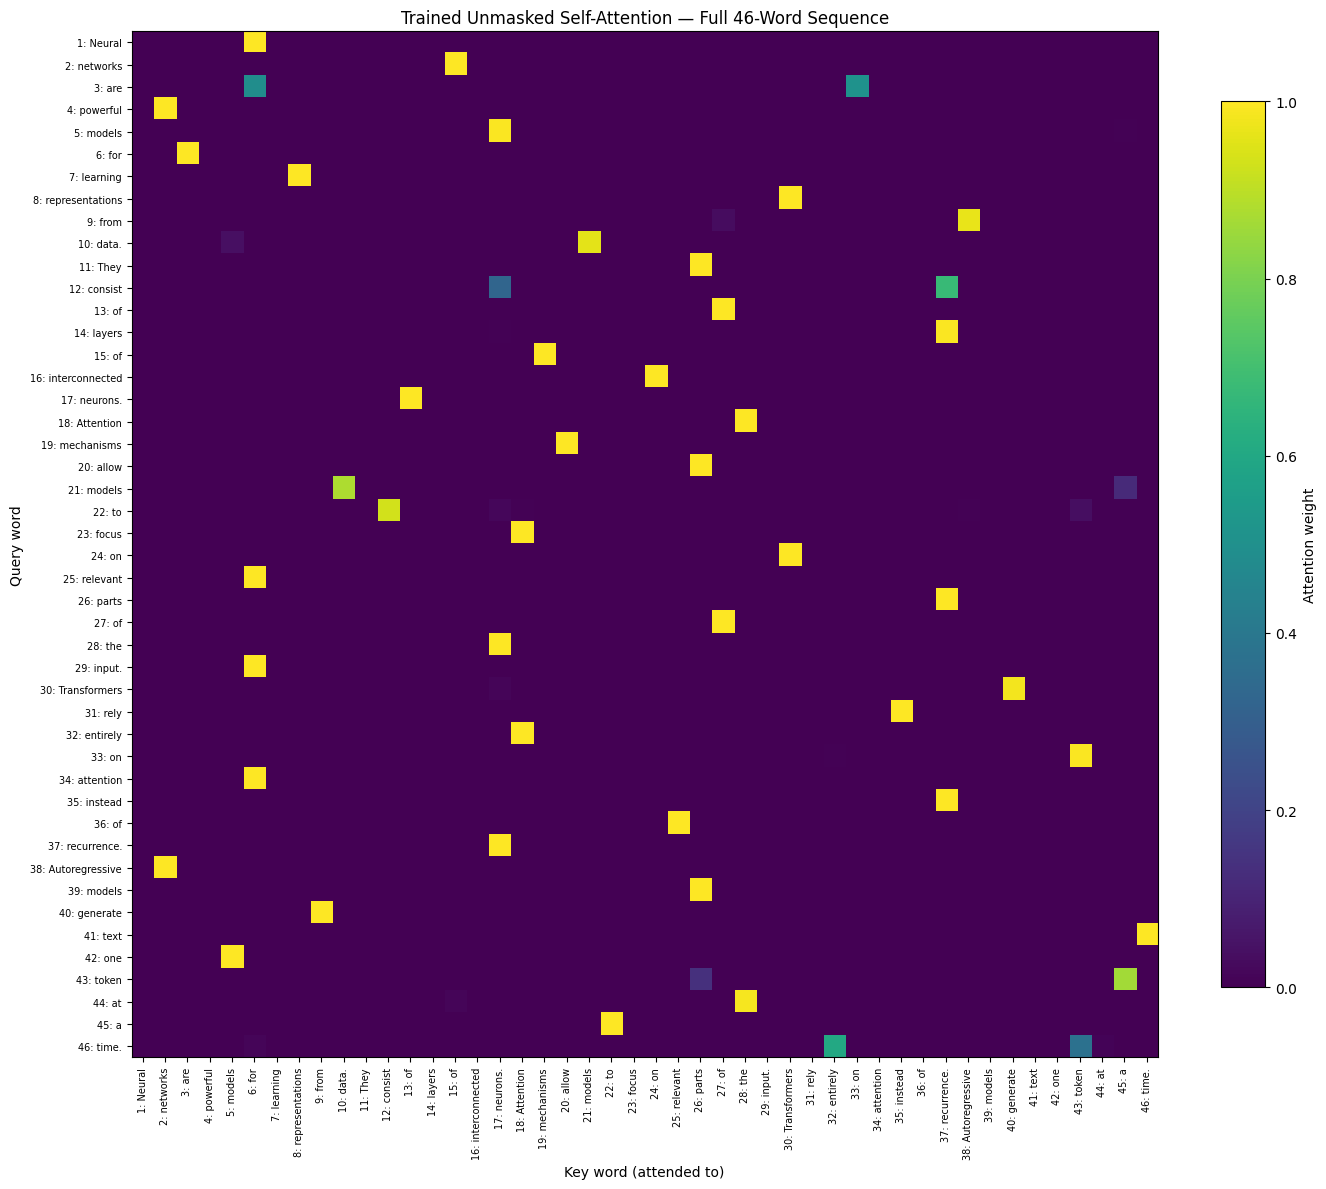

Heatmap saved: unmasked_heatmap.png


In [28]:
import matplotlib.pyplot as plt

def plot_attention(attention, title, filename):
    labels = [
        f"{index + 1}: {word}"
        for index, word in enumerate(tokens)
    ]

    fig, ax = plt.subplots(figsize=(14, 12))

    image = ax.imshow(
        attention,
        cmap="viridis",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    ax.set_xticks(
        range(sequence_length),
        labels=labels,
        rotation=90,
        fontsize=7
    )
    ax.set_yticks(
        range(sequence_length),
        labels=labels,
        fontsize=7
    )

    ax.set_xlabel("Key word (attended to)")
    ax.set_ylabel("Query word")
    ax.set_title(title)

    fig.colorbar(
        image, ax=ax,
        label="Attention weight",
        fraction=0.035
    )

    fig.tight_layout()
    fig.savefig(ARTIFACT_DIR / filename, dpi=180)
    plt.show()

    print("Heatmap saved:", filename)
    return fig


unmasked_heatmap_figure = plot_attention(
    unmasked_attention,
    "Trained Unmasked Self-Attention — Full 46-Word Sequence",
    "unmasked_heatmap.png"
)

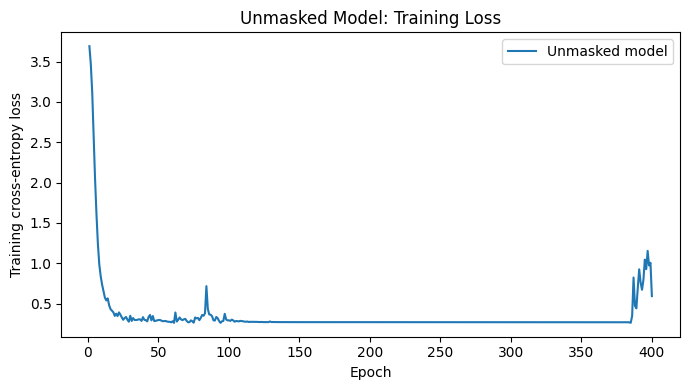

Maximum future attention weight: 1.0
Average attention mass on future words: 0.5427805185317993

Strongest attention links at selected positions:
1:Neural → 6:for | weight=1.0000 | future word=True
18:Attention → 28:the | weight=0.9999 | future word=True
30:Transformers → 40:generate | weight=0.9840 | future word=True
38:Autoregressive → 2:networks | weight=0.9997 | future word=False
46:time. → 32:entirely | weight=0.6031 | future word=False


In [29]:
unmasked_loss_figure, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    range(1, EPOCHS + 1),
    unmasked_losses,
    label="Unmasked model"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training cross-entropy loss")
ax.set_title("Unmasked Model: Training Loss")
ax.legend()

unmasked_loss_figure.tight_layout()
unmasked_loss_figure.savefig(
    ARTIFACT_DIR / "unmasked_training_loss.png", dpi=160
)
plt.show()

# Positions above the diagonal represent future words.
future_positions = np.triu(
    np.ones((sequence_length, sequence_length), dtype=bool),
    k=1
)

unmasked_metrics["Max future weight"] = float(
    unmasked_attention[future_positions].max()
)
unmasked_metrics["Mean future mass"] = float(
    np.where(future_positions, unmasked_attention, 0)
    .sum(axis=1).mean()
)

print("Maximum future attention weight:",
      unmasked_metrics["Max future weight"])
print("Average attention mass on future words:",
      unmasked_metrics["Mean future mass"])

print("\nStrongest attention links at selected positions:")
for query_index in [0, 17, 29, 37, 45]:
    key_index = int(unmasked_attention[query_index].argmax())

    print(
        f"{query_index + 1}:{tokens[query_index]} → "
        f"{key_index + 1}:{tokens[key_index]} | "
        f"weight={unmasked_attention[query_index, key_index]:.4f} | "
        f"future word={key_index > query_index}"
    )

pd.DataFrame([unmasked_metrics]).to_csv(
    ARTIFACT_DIR / "unmasked_metrics.csv", index=False
)
log_file.flush()

### Part 1 Findings

The exact paragraph produced **46 word tokens** and **40 unique words**.

After training:
- Loss decreased from **3.6906 to 0.6325**.
- Next-word training accuracy was **77.78%**.
- The word embeddings and Q/K/V projection weights all changed.
- The full attention matrix had shape **46 × 46**, and every row summed to 1.

The heatmap therefore shows learned attention weights rather than the random starting weights.

Training was not fully stable. The loss was about **0.2698 at epoch 300**, then increased near the end. A lower learning rate could be tested to reduce these fluctuations.

The unmasked model can use future words, including the word it is trying to predict. Also, training and evaluation used the same small paragraph. This accuracy measures training fit, not performance on unseen text or valid causal generation.

In [30]:
class CausalAttentionModel(SelfAttentionModel):
    def attend(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = (q @ k.T) / (self.embedding_dim ** 0.5)

        # Allow each word to attend to itself and earlier words.
        causal_mask = torch.tril(
            torch.ones(
                scores.shape,
                dtype=torch.bool,
                device=scores.device
            )
        )

        # Block future positions BEFORE applying softmax.
        masked_scores = scores.masked_fill(
            ~causal_mask, float("-inf")
        )

        attention_weights = torch.softmax(masked_scores, dim=-1)
        context = attention_weights @ v

        return context, attention_weights


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

masked_model = CausalAttentionModel(
    vocab_size, sequence_length, embedding_dim
).to(device)

# Start from the same initial weights as the unmasked model.
masked_model.load_state_dict(initial_model_state)

assert all(
    torch.equal(weight, initial_model_state[name])
    for name, weight in masked_model.state_dict().items()
)

print("Causal attention model created.")
print("Initial weights match the unmasked model's starting weights.")
print("Future positions will be blocked before softmax.")

Causal attention model created.
Initial weights match the unmasked model's starting weights.
Future positions will be blocked before softmax.


In [31]:
masked_losses, masked_metrics = train_attention(
    masked_model, "masked"
)


Training started: 2026-09-15T08:03:37.833148+00:00
Epoch 100: loss = 0.307146
Epoch 200: loss = 0.467722
Epoch 300: loss = 0.462175
Epoch 400: loss = 0.462142

Training results: {'Model': 'masked', 'Initial loss': 3.7070813179016113, 'Final loss': 0.4621417224407196, 'Training accuracy': 0.7111111283302307, 'Training seconds': 3.3820808830000715}
Checkpoint saved.


In [32]:
masked_parameter_changes = {}

for name in [
    "embedding.weight",
    "query.weight",
    "key.weight",
    "value.weight"
]:
    change = (
        masked_model.state_dict()[name] - initial_model_state[name]
    ).norm().item()

    masked_parameter_changes[name] = change
    assert change > 0, f"{name} did not change during training."
    print(f"{name}: weight change = {change:.6f}")

assert (
    masked_metrics["Final loss"] < masked_metrics["Initial loss"]
), "Training did not reduce the masked model's loss."

masked_model.eval()

with torch.no_grad():
    _, trained_masked_weights = masked_model(token_ids)

masked_attention = trained_masked_weights.cpu().numpy()

future_positions = np.triu(
    np.ones((sequence_length, sequence_length), dtype=bool),
    k=1
)

assert masked_attention.shape == (
    sequence_length, sequence_length
)
assert np.isfinite(masked_attention).all()
assert np.allclose(
    masked_attention.sum(axis=1), 1.0, atol=1e-6
)
assert np.all(masked_attention[future_positions] == 0)

masked_metrics["Max future weight"] = float(
    masked_attention[future_positions].max()
)
masked_metrics["Mean future mass"] = float(
    np.where(future_positions, masked_attention, 0)
    .sum(axis=1).mean()
)

np.save(
    ARTIFACT_DIR / "masked_attention.npy",
    masked_attention
)

(ARTIFACT_DIR / "masked_parameter_changes.json").write_text(
    json.dumps(masked_parameter_changes, indent=2)
)

pd.DataFrame([masked_metrics]).to_csv(
    ARTIFACT_DIR / "masked_metrics.csv", index=False
)

print("\nTrained masked attention shape:", masked_attention.shape)
print("Every attention row sums to 1.")
print("Maximum future weight:", masked_metrics["Max future weight"])
print("All future attention weights are zero.")
log_file.flush()

embedding.weight: weight change = 8.873141
query.weight: weight change = 10.476832
key.weight: weight change = 10.060288
value.weight: weight change = 7.488279

Trained masked attention shape: (46, 46)
Every attention row sums to 1.
Maximum future weight: 0.0
All future attention weights are zero.


### Visualize Trained Causal Attention

The next heatmap shows attention across all 46 words after training the masked model.

The upper triangle represents future positions and must be dark because those weights are zero. Words can attend only to positions on or below the diagonal.

I will use the same labels and color scale as the unmasked heatmap so the two plots are easier to compare.

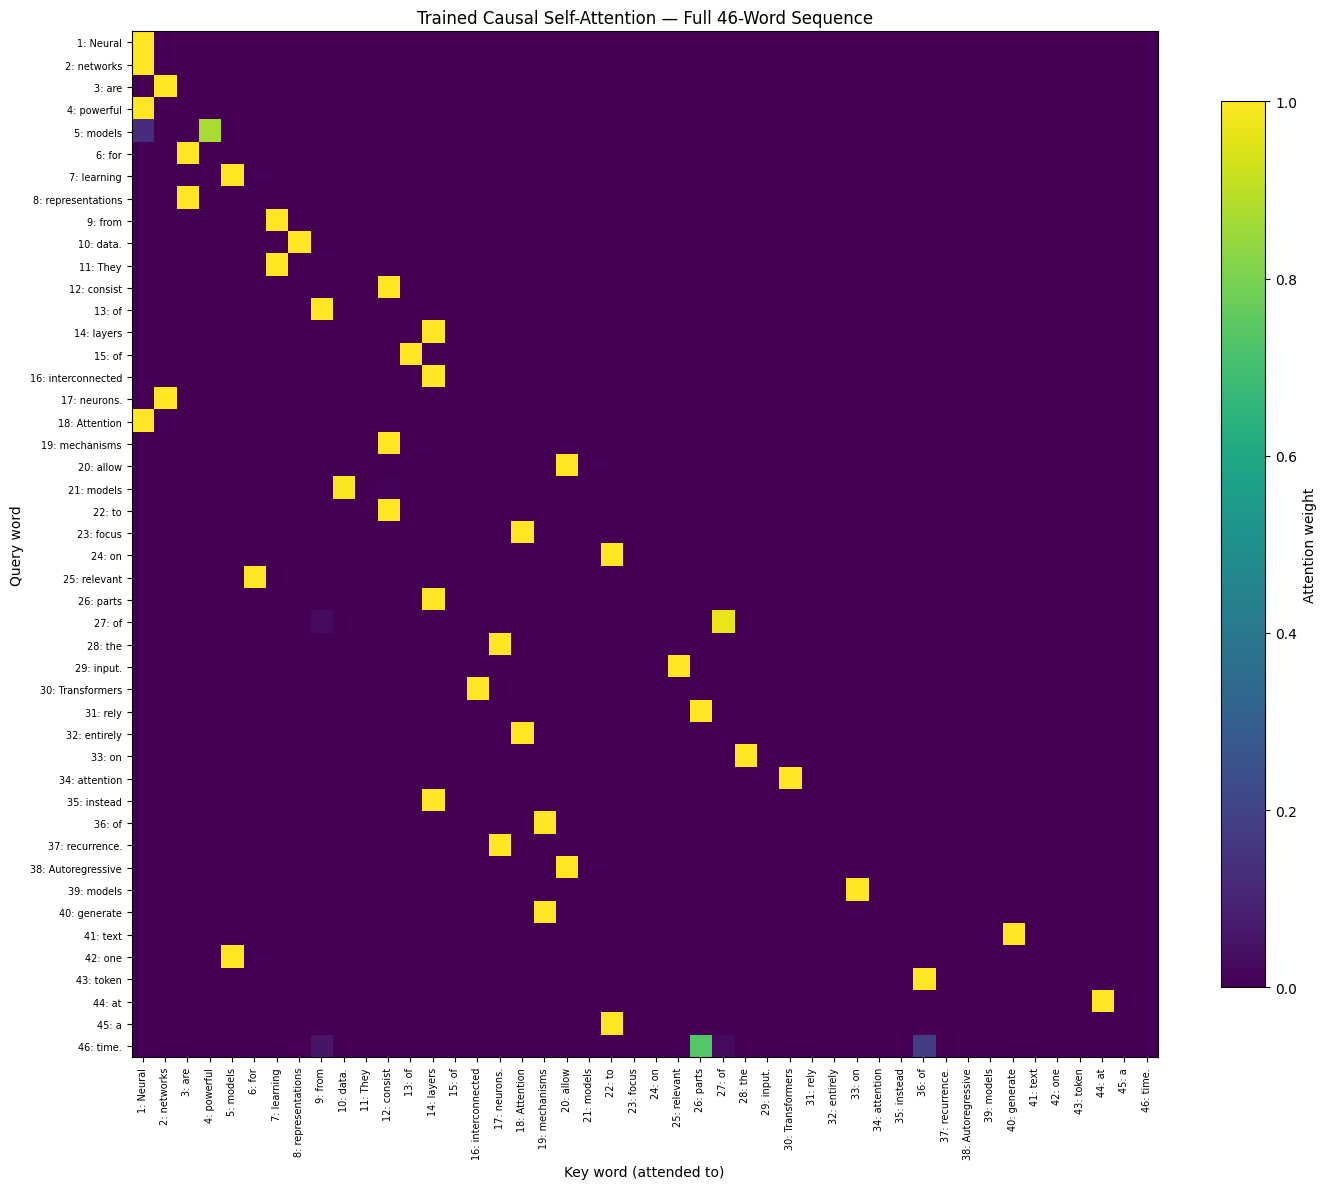

Heatmap saved: masked_heatmap.png


In [33]:
masked_heatmap_figure = plot_attention(
    masked_attention,
    "Trained Causal Self-Attention — Full 46-Word Sequence",
    "masked_heatmap.png"
)

Attention model comparison:


,Model,Initial loss,Final loss,Training accuracy,Training seconds,Max future weight,Mean future mass
0,unmasked,3.690619,0.632527,0.777778,2.144298,1.0,0.542781
1,masked,3.707081,0.462142,0.711111,3.382081,0.0,0.000000


   Model  Initial loss  Final loss  Training accuracy  Training seconds  Max future weight  Mean future mass
unmasked      3.690619    0.632527           0.777778          2.144298                1.0          0.542781
  masked      3.707081    0.462142           0.711111          3.382081                0.0          0.000000


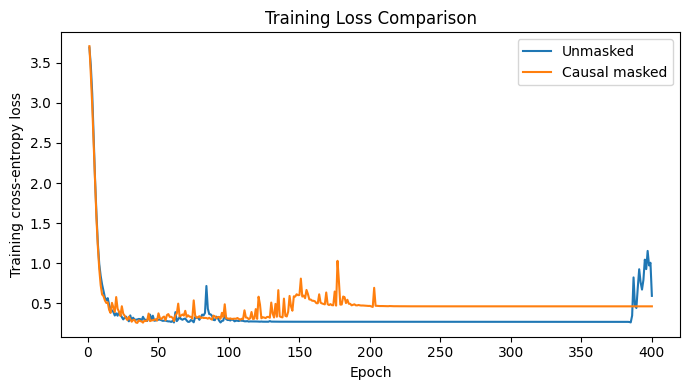


Largest change in earlier masked predictions: 0.0
Future-word change did not affect earlier predictions.


In [34]:
attention_df = pd.DataFrame([
    unmasked_metrics,
    masked_metrics
])

print("Attention model comparison:")
display(attention_df.round(6))
print(attention_df.round(6).to_string(index=False))

attention_df.to_csv(
    ARTIFACT_DIR / "attention_metrics.csv", index=False
)

# Plot both training histories.
combined_loss_figure, ax = plt.subplots(figsize=(7, 4))
epochs = range(1, EPOCHS + 1)

ax.plot(epochs, unmasked_losses, label="Unmasked")
ax.plot(epochs, masked_losses, label="Causal masked")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training cross-entropy loss")
ax.set_title("Training Loss Comparison")
ax.legend()

combined_loss_figure.tight_layout()
combined_loss_figure.savefig(
    ARTIFACT_DIR / "training_loss_comparison.png", dpi=160
)
plt.show()

# Change only the final word.
changed_token_ids = token_ids.clone()
changed_token_ids[-1] = (changed_token_ids[-1] + 1) % vocab_size

with torch.no_grad():
    original_logits, _ = masked_model(token_ids)
    changed_logits, _ = masked_model(changed_token_ids)

prefix_difference = (
    original_logits[:-1] - changed_logits[:-1]
).abs().max().item()

assert prefix_difference < 1e-6

print("\nLargest change in earlier masked predictions:",
      prefix_difference)
print("Future-word change did not affect earlier predictions.")

(ARTIFACT_DIR / "causal_check.json").write_text(
    json.dumps({"max_earlier_logit_change": prefix_difference}, indent=2)
)

log_file.flush()

### Part 2 Findings and Comparison

I trained the causal model separately using the same initial weights, 400 epochs, and learning rate of 0.01 as the unmasked model.

The masked model passed these checks:
- Its embeddings and Q/K/V projection weights changed during training.
- Its trained attention matrix had shape **46 × 46**.
- Every attention row summed to 1.
- Every future-position weight was exactly **0**.

The masked heatmap has a dark upper triangle because future words are blocked before softmax. The unmasked model has no such restriction.

The additional future-word test checks that changing the final word does not affect predictions at earlier positions.

The comparison table reports each model's training loss and accuracy. These scores need careful interpretation: the unmasked model can see future target words, while the causal model cannot.

Both models were evaluated on their training paragraph. Their results show learned attention and the effect of masking, but do not show how well they would perform on new text.

In [35]:
def markdown_table(frame):
    columns = list(frame.columns)

    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |"
    ]

    for row in frame.itertuples(index=False, name=None):
        lines.append(
            "| " + " | ".join(str(value) for value in row) + " |"
        )

    return "\n".join(lines)


parameters_text = (
    f"SID4={SID4}, SEED={SEED}, SLICE={SLICE}, "
    f"HP_ID={HP_ID}, CLS_A={CLS_A}, CLS_B={CLS_B}"
)

prompt_findings_text = (
    f"{int(prompt_df['Correct final'].sum())} of "
    f"{len(prompt_df)} final answers passed the checks. "
    "I compared the same math and logic tasks across six techniques. "
    "Longer explanations and additional model calls did not guarantee "
    "correct answers. Failed responses are retained in the notebook "
    "and saved output files. This is a small two-task experiment."
)

attention_findings_text = "\n\n".join(
    f"{row['Model']}: initial loss {row['Initial loss']:.4f}, "
    f"final loss {row['Final loss']:.6f}, "
    f"training accuracy {100 * row['Training accuracy']:.2f}%, "
    f"maximum future weight {row['Max future weight']:.6f}."
    for row in [unmasked_metrics, masked_metrics]
)

attention_findings_text += (
    "\n\nBoth models learned embeddings and Q/K/V projections. "
    "Both trained attention matrices cover all 46 words. "
    "The causal model has zero future attention. "
    "The unmasked model can access future target words. "
    "Both accuracies measure training fit on one paragraph."
    f"\n\nFuture-word check: maximum earlier-logit change "
    f"was {prefix_difference:.8f}."
)

metrics_text = (
    "# HW3 Metrics\n\n"
    + parameters_text
    + "\n\n## Prompt Experiments\n\n"
    + markdown_table(prompt_df.drop(columns="Output"))
    + "\n\n" + prompt_findings_text
    + "\n\n## Attention Models\n\n"
    + markdown_table(attention_df.round(6))
    + "\n\n" + attention_findings_text
)

(ARTIFACT_DIR / "METRICS.md").write_text(metrics_text)

training_calls = (
    "Run the Colab notebook from top to bottom.\n"
    "Exact training calls:\n"
    'unmasked_losses, unmasked_metrics = train_attention(unmasked_model, "unmasked")\n'
    'masked_losses, masked_metrics = train_attention(masked_model, "masked")\n'
    f"Seed={SEED}; epochs={EPOCHS}; learning_rate={LEARNING_RATE}; "
    f"embedding_dim={embedding_dim}; device={device}\n"
)

(ARTIFACT_DIR / "TRAINING_COMMAND.txt").write_text(training_calls)

print("METRICS.md and TRAINING_COMMAND.txt saved.")

METRICS.md and TRAINING_COMMAND.txt saved.
